<a href="https://colab.research.google.com/github/redouanelg/climatsuds-tutorials/blob/main/Data_Access/arraylake_era5_access.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Author · Auteur: [Redouane Lguensat](https://redouanelg.github.io) — IPSL/IRD*

In [1]:
!pip install arraylake pcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.4/587.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 6.4 MB/s eta 0:00:00


In [ ]:
from arraylake import Client
import xarray as xr
import matplotlib.pyplot as plt

client = Client()
client.login()  # EN: requires free Earthmover.io account. FR: Besoin de créer un compte gratuit sur Earthmover.io

repo = client.get_repo("earthmover-public/era5")
session = repo.readonly_session(branch="main")

# English:

Focusing on how the data is chunked is important for efficient access. This dataset by Earthmover is chunked in two ways temporal or spatial.

### Sub-groups explanation:
* spatial chunks are (time=1, latitude=721, longitude=1440)—one full global map per hour—so map-style and regional queries load fast.
* temporal chunks are (time=8736, latitude=12, longitude=12)—equivalent to 1 year of hourly data and small chunksizes in latitude and longitude ideal for temporal queries and machine learning work flows.

Both groups contains 18 hourly single-level surface variables on the 0.25° grid (1975-01-01 → 2024-12-31).

Check https://docs.earthmover.io/sample-data/era5 for more information

# French:
La manière dont les données sont découpées en blocs est essentielle pour garantir un accès efficace. Ce jeu de données d’Earthmover est organisé selon deux types de découpage : temporel et spatial.

### Explication des sous-groupes :

* Les blocs spatiaux ont les dimensions suivantes : (temps=1, latitude=721, longitude=1440). Chaque bloc correspond à une carte mondiale complète pour une heure donnée, ce qui permet de charger rapidement les requêtes cartographiques et régionales.

* Les blocs temporels ont les dimensions suivantes : (temps=8736, latitude=12, longitude=12). Ils correspondent à une année de données horaires, avec de petits blocs en latitude et en longitude, ce qui les rend particulièrement adaptés aux requêtes portant sur des séries chronologiques et aux flux de travail d’apprentissage automatique.

Les deux groupes contiennent 18 variables de surface horaires à un seul niveau, sur une grille de 0,25°, pour la période allant du 1er janvier 1975 au 31 décembre 2024.

Pour plus d’informations, consultez la documentation d’Earthmover : https://docs.earthmover.io/sample-data/era5

# Example with temporal access

In [3]:
ds = xr.open_zarr(session.store,  group="single/temporal", chunks=None)
ds

<xarray.Dataset> Size: 110TB
Dimensions:     (valid_time: 753888, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Data variables: (12/35)
    blh         (valid_time, latitude, longitude) float32 3TB ...
    cape        (valid_time, latitude, longitude) float32 3TB ...
    fsr         (valid_time, latitude, longitude) float32 3TB ...
    cp          (valid_time, latitude, longitude) float32 3TB ...
    ie          (valid_time, latitude, longitude) float32 3TB ...
    d2m         (valid_time, latitude, longitude) float32 3TB ...
    ...          ...
    tsr         (valid_time, latitude, longitude) float32 3TB ...
    u10         (valid_time, latitude, longitude) float32 3TB ...
    u100        (valid_time, latitude, longitude) float32 3TB ...
    v10         (valid_time, latitude, longitude) float32 3TB ...
    zust        (valid_time, latitude, longitude) float32 3TB ...
    v100        (valid_time, latitude, longitude) float32 3TB ...
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for t...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-10T20:01 GRIB to CDM+CF via cfgrib-0....

In [4]:
# pull a timeseries
ts = ds.t2m.sel(longitude=106, latitude=4, valid_time=slice("2000", "2025")).load()
ts

<xarray.DataArray 't2m' (valid_time: 227928)> Size: 912kB
array([297.8272 , 298.03644, 298.31567, ..., 299.1545 , 299.04553,
       299.00607], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2MB 2000-01-01 ... 2025-12-31T23:...
    longitude   float64 8B 106.0
    latitude    float64 8B 4.0
    lsm         float32 4B nan
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

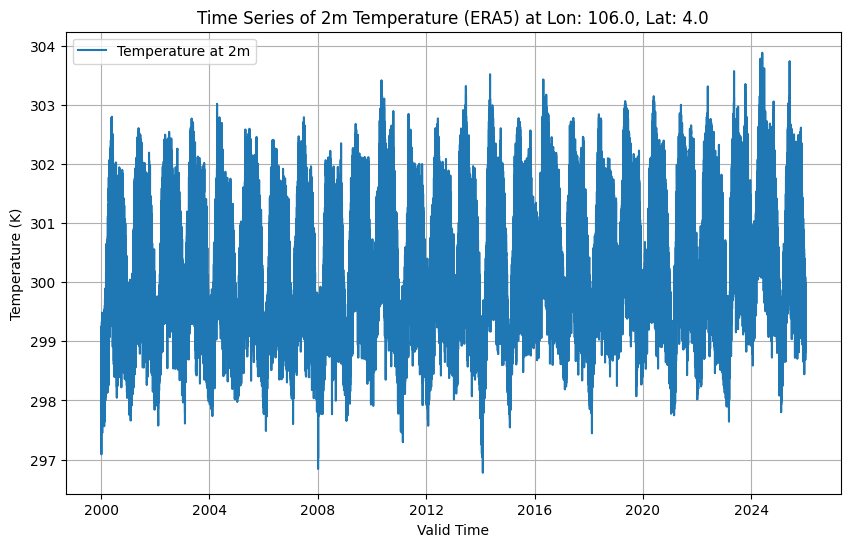

In [5]:
plt.figure(figsize=(10, 6))
ts.plot(label='Temperature at 2m')
# Extract longitude and latitude from the xarray DataArray 'ts'
lon = ts.longitude.item() if hasattr(ts.longitude, 'item') else ts.longitude
lat = ts.latitude.item() if hasattr(ts.latitude, 'item') else ts.latitude
plt.title(f'Time Series of 2m Temperature (ERA5) at Lon: {lon}, Lat: {lat}')
plt.xlabel('Valid Time')
plt.ylabel('Temperature (K)')
plt.grid(True)
plt.legend()
plt.show()

# Example with efficient spatial access

In [6]:
ds_spatial = xr.open_zarr(session.store,  group="single/spatial", chunks=None)
ds_spatial

<xarray.Dataset> Size: 110TB
Dimensions:     (valid_time: 753888, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Data variables: (12/35)
    blh         (valid_time, latitude, longitude) float32 3TB ...
    cape        (valid_time, latitude, longitude) float32 3TB ...
    cp          (valid_time, latitude, longitude) float32 3TB ...
    d2m         (valid_time, latitude, longitude) float32 3TB ...
    fsr         (valid_time, latitude, longitude) float32 3TB ...
    fg10        (valid_time, latitude, longitude) float32 3TB ...
    ...          ...
    tsr         (valid_time, latitude, longitude) float32 3TB ...
    u10         (valid_time, latitude, longitude) float32 3TB ...
    u100        (valid_time, latitude, longitude) float32 3TB ...
    v10         (valid_time, latitude, longitude) float32 3TB ...
    v100        (valid_time, latitude, longitude) float32 3TB ...
    zust        (valid_time, latitude, longitude) float32 3TB ...
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for s...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-10T20:01 GRIB to CDM+CF via cfgrib-0....

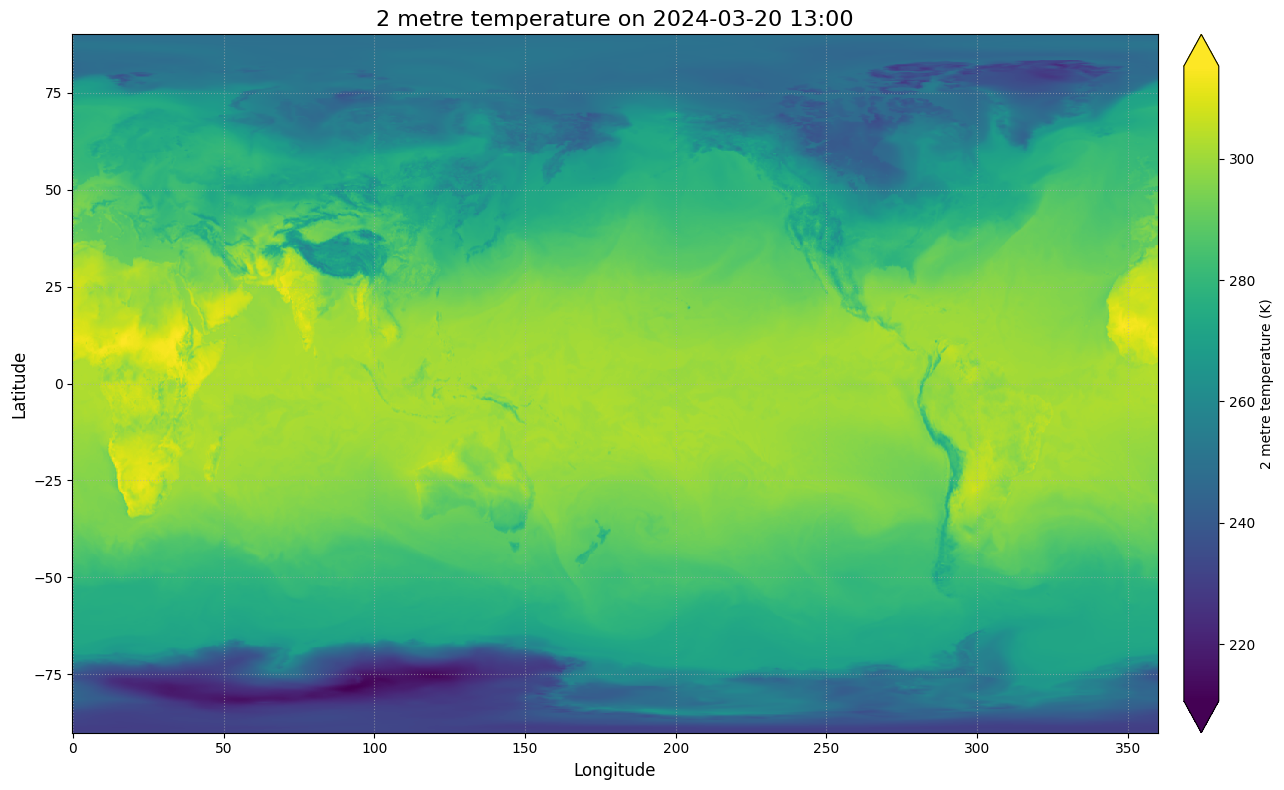

In [7]:
import numpy as np

# Select a random day (time index)
random_idx = np.random.randint(0, len(ds_spatial['valid_time']))
random_day_data = ds_spatial.isel(valid_time=random_idx)

# Choose a variable to plot. 't2m' (2m temperature) is a good candidate for visualization.
# If 't2m' is not available, we could pick another suitable variable.
if 't2m' in random_day_data.data_vars:
    data_to_plot = random_day_data['t2m']
else:
    # Fallback to the first available data variable if t2m is not present
    print("Warning: 't2m' variable not found, plotting the first available data variable.")
    data_to_plot = random_day_data[list(random_day_data.data_vars)[0]]

# Get the exact time for the title
plot_time = data_to_plot['valid_time'].dt.strftime('%Y-%m-%d %H:%M').item()

# Create a pretty plot
plt.figure(figsize=(14, 8))
p = data_to_plot.plot.pcolormesh(
    x='longitude',
    y='latitude',
    cmap='viridis',  # 'viridis' is a good perceptually uniform colormap
    add_colorbar=True,
    cbar_kwargs={
        'label': f'{data_to_plot.attrs.get("long_name", data_to_plot.name)} ({data_to_plot.attrs.get("units", "K")})',
        'orientation': 'vertical',
        'pad': 0.02
    },
    extend='both' # Extends colorbar for values outside the normal range
)

plt.title(
    f'{data_to_plot.attrs.get("long_name", data_to_plot.name)} on {plot_time}',
    fontsize=16
)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()